# **8. 뉴스 요약봇 만들기 [프로젝트]**

## **8-1. 프로젝트: 뉴스기사 요약해보기**

새로운 데이터셋에 대해서 추상적 요약과 추출적 요약을 모두 해보는 시간을 가져봐요.<br>
<br>
먼저 주요 라이브러리 버전을 확인해 보죠.

In [1]:
!pip install --upgrade summa

In [2]:
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

import torch
from collections import Counter

import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heeji\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Step 1. 데이터 수집하기**

데이터는 아래 링크에 있는 뉴스 기사 데이터(`news_summary_more.csv`)를 사용하세요.<br>
<br>
- [sunnysai12345/News_Summary](https://github.com/sunnysai12345/News_Summary)<br><br>

아래의 코드로 데이터를 다운로드할 수 있어요.

In [3]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [4]:
data.sample(10)

,headlines,text
20265,"Your English, spellings are so poor: Rishi Kap...",Trolling a fan who appreciated his performance...
49155,Only AIADMK cardholders will get govt help: TN...,Tamil Nadu Cooperatives Minister Sellur Raju h...
48125,Rahul Gandhi's convoy shown black flags by mob...,Congress President Rahul Gandhi's convoy was s...
52831,Hundreds of bats die due to 80-year record hea...,Over 400 bats died in one colony alone as temp...
21419,Berkshire Hathaway's Apple stake now worth $53...,World's third-richest person Warren Buffett's ...
50071,Belgian eateries sued for selling 'mineral wat...,Two Belgian restaurants have been sued for all...
5027,Vedanta to challenge Madras HC's order on Ster...,Vedanta has said it would move Supreme Court t...
38276,Bullet-ridden body of abducted Army jawan reco...,"The bullet-ridden body of Indian Army jawan, A..."
9067,Cabinet approves medical college in Dadra and ...,The Union Cabinet on Thursday approved the set...
31319,"J&K cop on way to mosque foils terror bid, get...",A policeman on his way to offer prayers at a m...


이 데이터는 기사의 본문에 해당되는 text와 headlines 두 가지 열로 구성되어져 있습니다.<br>
<br>
추상적 요약을 하는 경우에는 text를 본문, headlines를 이미 요약된 데이터로 삼아서 모델을 학습할 수 있어요. 추출적 요약을 하는 경우에는 오직 text열만을 사용하세요.

### **Step 2. 데이터 전처리하기 (추상적 요약)**

실습에서 사용된 전처리를 참고하여 각자 필요하다고 생각하는 전처리를 추가 사용하여 텍스트를 정규화 또는 정제해 보세요. 만약, 불용어 제거를 선택한다면 상대적으로 길이가 짧은 요약 데이터에 대해서도 불용어를 제거하는 것이 좋을지 고민해 보세요.

#### 중복 제거

In [5]:
print('data 총 개수: ', len(data))
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

data 총 개수:  98401
text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280


In [6]:
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [7]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


#### 텍스트 정규화 및 불용어 제거

In [8]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [26]:
# 불용어 사전은 한 번만 만들어 set으로 캐싱
stop_words = set(stopwords.words('english'))

# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if word not in stop_words if len(word) > 1)
    # 불용어 미제거 (headline)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [10]:
# 전체 text 데이터에 대한 전처리
from tqdm import tqdm
clean_text = []

for sentence in tqdm(data['text']):
    clean_text.append(preprocess_sentence(sentence))

# 전처리 후 출력
print("Text 전처리 후 결과: ", clean_text[:5])

100%|██████████| 98360/98360 [00:13<00:00, 7440.47it/s]

Text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [11]:
# 전체 headline 데이터에 대한 전처리
from tqdm import tqdm
clean_headline = []

for sentence in tqdm(data['headlines']):
    clean_headline.append(preprocess_sentence(sentence, remove_stopwords=False))

print("headline 전처리 후 결과: ", clean_headline[:5])

100%|██████████| 98360/98360 [00:10<00:00, 9742.16it/s] 

headline 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [12]:
# 전처리 후 null값 처리
data['text'] = clean_text
data['headlines'] = clean_headline

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)
data.isnull().sum()

headlines    0
text         0
dtype: int64

In [13]:
# 전처리 결과 저장 — 커널을 재시작해도 위의 전처리 셀을 다시 돌리지 않아도 된다
import os
os.makedirs('data', exist_ok=True)
data.to_pickle('data/preprocessed.pkl')
print('저장 완료:', len(data), '행 ->', os.path.abspath('data/preprocessed.pkl'))

# 재시작 후에는 위 전처리 셀들을 건너뛰고 아래 한 줄만 실행하면 된다
# data = pd.read_pickle('data/preprocessed.pkl')

저장 완료: 98360 행 -> C:\Aiffel\AIFFEL_quest_rs\Exploration\Ex08\data\preprocessed.pkl


#### 샘플 최대 길이 설정

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
헤드라인의 최소 길이 : 1
헤드라인의 최대 길이 : 16
헤드라인의 평균 길이 : 9.299532330215534


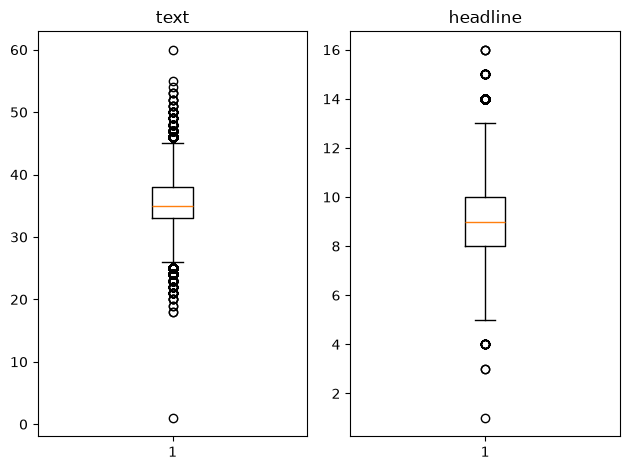

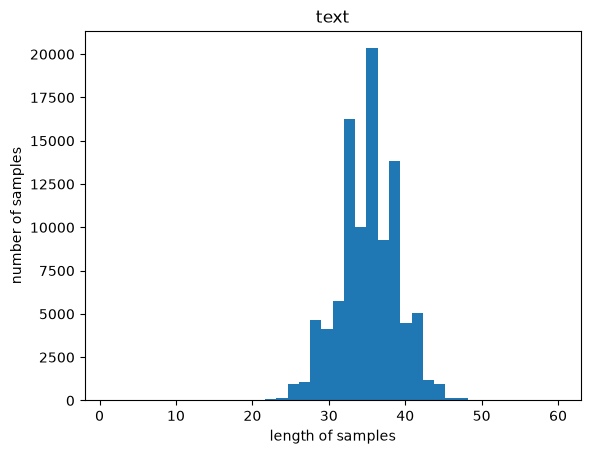

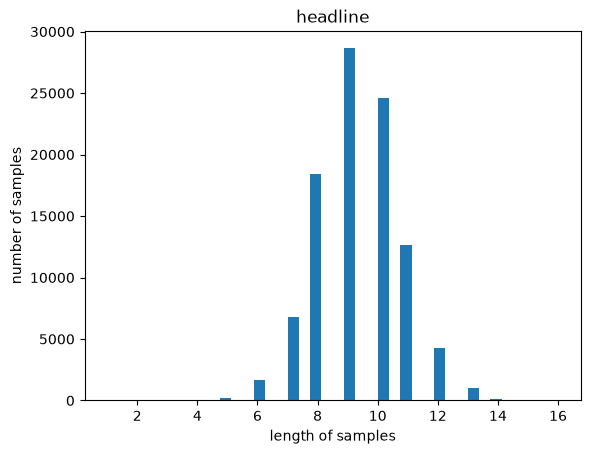

In [14]:
# 길이 분포 출력
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
headline_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('헤드라인의 최소 길이 : {}'.format(np.min(headline_len)))
print('헤드라인의 최대 길이 : {}'.format(np.max(headline_len)))
print('헤드라인의 평균 길이 : {}'.format(np.mean(headline_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('text')
plt.subplot(1,2,2)
plt.boxplot(headline_len)
plt.title('headline')
plt.tight_layout()
plt.show()

plt.title('text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('headline')
plt.hist(headline_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [15]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [16]:
text_max_len = 40
headline_max_len = 15

below_threshold_len(text_max_len, data['text'])
below_threshold_len(headline_max_len, data['headlines'])

전체 샘플 중 길이가 40 이하인 샘플의 비율: 0.9238714924766165
전체 샘플 중 길이가 15 이하인 샘플의 비율: 0.9999694997966653


In [17]:
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headline_max_len)]

print('전체 샘플수 :', (len(data)))

전체 샘플수 : 90869


#### Decoder 데이터에 시작/종료 토큰 추가

In [18]:
# 시작 토큰 = SOS, 종료 토큰 = EOS
data['decoder_input'] = data['headlines'].apply(lambda x : 'SOS ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' EOS')

data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,SOS upgrad learner switches to career in ml al...,upgrad learner switches to career in ml al wit...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,SOS new zealand end rohit sharma led india mat...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,SOS aegon life iterm insurance plan helps cust...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...,SOS have known hirani for yrs what if metoo cl...,have known hirani for yrs what if metoo claims...
5,rahat fateh ali khan denies getting notice for...,pakistani singer rahat fateh ali khan denied r...,SOS rahat fateh ali khan denies getting notice...,rahat fateh ali khan denies getting notice for...


In [107]:
# numpy로 변환
encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블

#### 훈련 / 검증 / 테스트 데이터 분할

In [108]:
np.random.seed(42)
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

# train 80% / validation 10% / test 10%
n_of_test  = int(len(encoder_input) * 0.1)
n_of_val   = int(len(encoder_input) * 0.1)
n_of_train = len(encoder_input) - n_of_val - n_of_test

encoder_input_train  = encoder_input[:n_of_train]
decoder_input_train  = decoder_input[:n_of_train]
decoder_target_train = decoder_target[:n_of_train]

encoder_input_val  = encoder_input[n_of_train:n_of_train + n_of_val]
decoder_input_val  = decoder_input[n_of_train:n_of_train + n_of_val]
decoder_target_val = decoder_target[n_of_train:n_of_train + n_of_val]

encoder_input_test  = encoder_input[n_of_train + n_of_val:]
decoder_input_test  = decoder_input[n_of_train + n_of_val:]
decoder_target_test = decoder_target[n_of_train + n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('검증 데이터의 개수 :', len(encoder_input_val))
print('검증 레이블의 개수 :', len(decoder_input_val))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 72697
훈련 레이블의 개수 : 72697
검증 데이터의 개수 : 9086
검증 레이블의 개수 : 9086
테스트 데이터의 개수 : 9086
테스트 레이블의 개수 : 9086


#### vocabulary 만들기 및 정수 인코딩

In [109]:
from collections import Counter

def tokenize(text):
    return text.split()

def count_words(texts):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    return counter

def report_vocab(counter, threshold, name):
    """전체 단어 개수 및 등장 빈도 출력하고 counter를 그대로 반환"""
    total_cnt = len(counter)  # 전체 단어 개수
    total_freq = sum(counter.values())  # 전체 단어 등장 횟수
    rare_cnt = sum(1 for count in counter.values() if count < threshold)  # 희귀 단어 개수
    rare_freq = sum(count for count in counter.values() if count < threshold)  # 희귀 단어 등장 횟수

    print('[%s] 단어 집합(vocabulary)의 크기 :' % name, total_cnt)
    print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
    print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
    print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
    print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)
    print()
    return counter

def build_vocab(counter, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    for word, _ in counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_sequence(texts, vocab):
    unk = vocab["<UNK>"]
    return [[vocab.get(w, unk) for w in tokenize(t)] for t in texts]

In [110]:
src_threshold = 4
tar_threshold = 3

src_counter = report_vocab(count_words(encoder_input_train), threshold=src_threshold, name='text')

tar_counter = count_words(decoder_input_train)
tar_counter['EOS'] = tar_counter['SOS']
tar_counter = report_vocab(tar_counter, threshold=tar_threshold, name='headlines')

[text] 단어 집합(vocabulary)의 크기 : 65717
등장 빈도가 3번 이하인 희귀 단어의 수: 37581
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 28136
단어 집합에서 희귀 단어의 비율: 57.18611622563415
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 2.2636897137738488

[headlines] 단어 집합(vocabulary)의 크기 : 28968
등장 빈도가 2번 이하인 희귀 단어의 수: 14110
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 14858
단어 집합에서 희귀 단어의 비율: 48.708920187793424
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 2.181498960205329



In [111]:
src_vocab_size = 28000
tar_vocab_size = 14000

# 단어 집합은 훈련 데이터로만 만든다
src_vocab = build_vocab(src_counter, src_vocab_size)
tar_vocab = build_vocab(tar_counter, tar_vocab_size)

encoder_input_train_seq  = text_to_sequence(encoder_input_train,  src_vocab)
encoder_input_val_seq    = text_to_sequence(encoder_input_val,    src_vocab)
encoder_input_test_seq   = text_to_sequence(encoder_input_test,   src_vocab)

decoder_input_train_seq  = text_to_sequence(decoder_input_train,  tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_val_seq    = text_to_sequence(decoder_input_val,    tar_vocab)
decoder_target_val_seq   = text_to_sequence(decoder_target_val,   tar_vocab)
decoder_input_test_seq   = text_to_sequence(decoder_input_test,   tar_vocab)
decoder_target_test_seq  = text_to_sequence(decoder_target_test,  tar_vocab)

print('src_vocab :', len(src_vocab), '/ tar_vocab :', len(tar_vocab))
print('input  :', decoder_input_train_seq[:2])
print('target :', decoder_target_train_seq[:2])

src_vocab : 28000 / tar_vocab : 14000
input  : [[2, 1048, 81, 395, 11067, 223, 6513, 4, 540, 709, 640], [2, 215, 20, 19, 432, 181, 502, 19, 1, 1]]
target : [[1048, 81, 395, 11067, 223, 6513, 4, 540, 709, 640, 3], [215, 20, 19, 432, 181, 502, 19, 1, 1, 3]]


In [112]:
# 결측치 제거
drop_train = [index for index, seq in enumerate(decoder_input_train_seq) if len(seq) <= 1]
drop_val   = [index for index, seq in enumerate(decoder_input_val_seq)   if len(seq) <= 1]
drop_test  = [index for index, seq in enumerate(decoder_input_test_seq)  if len(seq) <= 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 검증 데이터의 개수 :', len(drop_val))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

def _filter(seqs, drop):
    dropset = set(drop)
    return [s for i, s in enumerate(seqs) if i not in dropset]

encoder_input_train_seq  = _filter(encoder_input_train_seq,  drop_train)
decoder_input_train_seq  = _filter(decoder_input_train_seq,  drop_train)
decoder_target_train_seq = _filter(decoder_target_train_seq, drop_train)

encoder_input_val_seq  = _filter(encoder_input_val_seq,  drop_val)
decoder_input_val_seq  = _filter(decoder_input_val_seq,  drop_val)
decoder_target_val_seq = _filter(decoder_target_val_seq, drop_val)

encoder_input_test_seq  = _filter(encoder_input_test_seq,  drop_test)
decoder_input_test_seq  = _filter(decoder_input_test_seq,  drop_test)
decoder_target_test_seq = _filter(decoder_target_test_seq, drop_test)

print('훈련 데이터의 개수 :', len(encoder_input_train_seq))
print('검증 데이터의 개수 :', len(encoder_input_val_seq))
print('테스트 데이터의 개수 :', len(encoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 검증 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 72697
검증 데이터의 개수 : 9086
테스트 데이터의 개수 : 9086


In [113]:
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    padded = torch.full((len(sequences), maxlen), padding_value, dtype=torch.long)
    for i, seq in enumerate(sequences):
        seq = seq[:maxlen]  # 앞에서부터 maxlen개만 사용 (뒤를 자름)
        padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    return padded


decoder_max_len = headline_max_len + 1  # SOS 또는 EOS 한 자리

encoder_input_train  = pad_sequences_pytorch(encoder_input_train_seq,  maxlen=text_max_len)
encoder_input_val    = pad_sequences_pytorch(encoder_input_val_seq,    maxlen=text_max_len)
encoder_input_test   = pad_sequences_pytorch(encoder_input_test_seq,   maxlen=text_max_len)

decoder_input_train  = pad_sequences_pytorch(decoder_input_train_seq,  maxlen=decoder_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=decoder_max_len)
decoder_input_val    = pad_sequences_pytorch(decoder_input_val_seq,    maxlen=decoder_max_len)
decoder_target_val   = pad_sequences_pytorch(decoder_target_val_seq,   maxlen=decoder_max_len)
decoder_input_test   = pad_sequences_pytorch(decoder_input_test_seq,   maxlen=decoder_max_len)
decoder_target_test  = pad_sequences_pytorch(decoder_target_test_seq,  maxlen=decoder_max_len)

print('train :', encoder_input_train.shape, decoder_input_train.shape, decoder_target_train.shape)
print('val   :', encoder_input_val.shape,   decoder_input_val.shape,   decoder_target_val.shape)
print('test  :', encoder_input_test.shape,  decoder_input_test.shape,  decoder_target_test.shape)

train : torch.Size([72697, 40]) torch.Size([72697, 16]) torch.Size([72697, 16])
val   : torch.Size([9086, 40]) torch.Size([9086, 16]) torch.Size([9086, 16])
test  : torch.Size([9086, 40]) torch.Size([9086, 16]) torch.Size([9086, 16])


### **Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)**

#### Train Model

In [114]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4)

In [115]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=2):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4)

In [116]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.scale = hidden_size ** 0.5

    def forward(self, decoder_output, encoder_outputs, src_mask):
        # decoder_output  : (B, L_tgt, H)
        # encoder_outputs : (B, L_src, H)
        # src_mask        : (B, L_src)  실제 단어=True, <PAD>=False
        
        # 디코더의 각 시점 × 인코더의 각 위치에 대한 점수 (B, L_tgt, L_src)
        scores = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2)) / self.scale
        scores = scores.masked_fill(~src_mask.unsqueeze(1), float('-inf'))  # 패딩 위치 제외
        attn_weights = F.softmax(scores, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)  # 가중치를 원문 표현에 가중합
        # -> (B, L_tgt, H)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size, dropout=0.3):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.dropout = nn.Dropout(dropout)                     # 출력층 직전 정규화
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 인코더 입력에서 <PAD>가 아닌 위치만 True
        src_mask = (encoder_input != 0)  # (B, L_src)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs, src_mask)  # (B, L_tgt, H)

        # 어텐션 결과와 디코더 출력 연결
        # decoder_outputs: 지금까지 모델이 생성한 문맥
        # attn_out: 원문에서 지금 참조할 부분
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(self.dropout(decoder_concat_output))

        return output


# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(28000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(14000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=256, out_features=14000, bias=True)
)


<img src="images/Attention_Architecture.png" width="25%">

#### Training

In [117]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 3

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
val_dataset   = TensorDataset(encoder_input_val,   decoder_input_val,   decoder_target_val)
test_dataset  = TensorDataset(encoder_input_test,  decoder_input_test,  decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

Using device: cuda


In [118]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    best_state = None
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산 (test set은 여기서 쓰지 않는다)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in val_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # 가장 좋았던 시점의 가중치 따로 보관
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # 학습 종료 후 최적 가중치로 되돌린다
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Best val loss: {best_val_loss:.4f}")

In [119]:
%%time
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 7.1004 | Val Loss: 6.7079
Epoch 2/50 | Train Loss: 6.5931 | Val Loss: 6.2594
Epoch 3/50 | Train Loss: 6.1023 | Val Loss: 5.8309
Epoch 4/50 | Train Loss: 5.7224 | Val Loss: 5.5455
Epoch 5/50 | Train Loss: 5.4359 | Val Loss: 5.3499
Epoch 6/50 | Train Loss: 5.1895 | Val Loss: 5.1687
Epoch 7/50 | Train Loss: 4.9742 | Val Loss: 5.0326
Epoch 8/50 | Train Loss: 4.7840 | Val Loss: 4.9259
Epoch 9/50 | Train Loss: 4.6144 | Val Loss: 4.8431
Epoch 10/50 | Train Loss: 4.4594 | Val Loss: 4.7689
Epoch 11/50 | Train Loss: 4.3232 | Val Loss: 4.7208
Epoch 12/50 | Train Loss: 4.1965 | Val Loss: 4.6699
Epoch 13/50 | Train Loss: 4.0796 | Val Loss: 4.6465
Epoch 14/50 | Train Loss: 3.9706 | Val Loss: 4.6162
Epoch 15/50 | Train Loss: 3.8690 | Val Loss: 4.6055
Epoch 16/50 | Train Loss: 3.7717 | Val Loss: 4.5974
Epoch 17/50 | Train Loss: 3.6840 | Val Loss: 4.5962
Epoch 18/50 | Train Loss: 3.5990 | Val Loss: 4.5884
Epoch 19/50 | Train Loss: 3.5205 | Val Loss: 4.5881
Epoch 20/50 | Train L

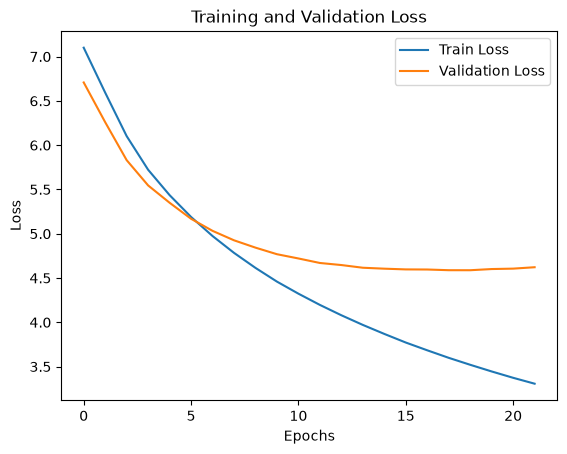

In [120]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

In [121]:
# 학습에 한 번도 쓰이지 않은 test set으로 최종 성능을 측정한다
# 반복 변수는 enc_in / dec_in / tgt 로 둔다.
# encoder_input, decoder_input 이라는 이름을 쓰면 셀 30에서 만든 전역 변수를 덮어써서
# 이후 셀 32(분할)를 다시 실행할 때 마지막 배치만 분할되는 문제가 생긴다.
model.eval()
test_loss = 0
with torch.no_grad():
    for enc_in, dec_in, tgt in test_loader:
        enc_in = enc_in.to(device).long()
        dec_in = dec_in.to(device).long()
        tgt = tgt.to(device).long()

        output = model(enc_in, dec_in)
        output = output.view(-1, output.shape[-1])
        tgt = tgt.view(-1)

        test_loss += criterion(output, tgt).item()

test_loss /= len(test_loader)
print(f"Test Loss : {test_loss:.4f}")

Test Loss : 4.5626


#### Inference Model

In [123]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [124]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # 인퍼런스 단계에서는 평가 모드로 전환합니다. (dropout 등 비활성화)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(28000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(14000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=256, out_features=14000, bias=True)
)

In [125]:
# 훈련된 Seq2SeqWithAttention 모델의 구성요소(디코더/어텐션/결합층/출력층)를
# 그대로 재사용하여 '한 스텝'씩 단어를 생성하는 래퍼입니다.
# 새로운 파라미터를 만들지 않으므로 훈련된 가중치가 그대로 사용됩니다.
class InferenceDecoder(nn.Module):
    def __init__(self, model):
        super(InferenceDecoder, self).__init__()
        self.decoder = model.decoder            # 학습된 디코더 LSTM
        self.attention = model.attention        # 학습된 어텐션
        self.concat = model.concat              # 학습된 결합층
        self.dropout = model.dropout            # 학습된 dropout (eval 모드에서는 그대로 통과)
        self.output_layer = model.output_layer  # 학습된 출력층

    def forward(self, decoder_input, hidden, cell, encoder_outputs, src_mask):
        # decoder_input: (1, 1)  -> 한 시점의 토큰 하나
        decoder_outputs, hidden, cell = self.decoder(decoder_input, hidden, cell)

        attn_out = self.attention(decoder_outputs, encoder_outputs, src_mask)

        concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))
        logits = self.output_layer(self.dropout(concat_output))  # (1, 1, vocab)
        return logits, hidden, cell


inference_decoder = InferenceDecoder(model)
inference_decoder.to(device)
inference_decoder.eval()

InferenceDecoder(
  (decoder): Decoder(
    (embedding): Embedding(14000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=256, out_features=14000, bias=True)
)

In [126]:
def decode_sequence(input_seq, model, inference_decoder, tar_word_to_index,
                    tar_index_to_word, headline_max_len, device):
    model.eval()
    inference_decoder.eval()

    # 입력을 (1, src_len) 텐서로 변환
    if not torch.is_tensor(input_seq):
        input_seq = torch.tensor(input_seq, dtype=torch.long)
    input_seq = input_seq.to(device).long()
    if input_seq.dim() == 1:
        input_seq = input_seq.unsqueeze(0)

    src_mask = (input_seq != 0)  # 학습 때와 동일한 패딩 마스크

    # 인코더는 한 번만 실행하여 인코더 출력과 초기 상태(hidden, cell)를 얻는다
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_seq)

    # 시작 토큰(SOS)으로 디코딩을 시작한다
    target_seq = torch.tensor([[tar_word_to_index['SOS']]], dtype=torch.long, device=device)

    decoded_words = []
    for _ in range(headline_max_len):
        with torch.no_grad():
            logits, hidden, cell = inference_decoder(target_seq, hidden, cell,
                                                     encoder_outputs, src_mask)

        sampled_token_index = int(torch.argmax(logits[0, -1, :]).item())
        sampled_token = tar_index_to_word.get(sampled_token_index, '')

        # 종료 토큰을 만나면 중단
        if sampled_token == 'EOS':
            break
        if sampled_token not in ('', '<PAD>', '<UNK>', 'SOS'):
            decoded_words.append(sampled_token)

        # 방금 예측한 토큰을 다음 시점의 입력으로 사용
        target_seq = torch.tensor([[sampled_token_index]], dtype=torch.long, device=device)

    return ' '.join(decoded_words)

In [127]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2headline(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['SOS'] and key != tar_word_to_index['EOS']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

In [128]:
%%time
for i in range(50, 100):
    print("원문      :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2headline(decoder_input_test[i]))
    print("예측 요약 :", decode_sequence(encoder_input_test[i], model, inference_decoder,
                                     tar_word_to_index, tar_index_to_word,
                                     headline_max_len, device))
    print()

원문      : actor piyush mishra revealed initially offered salman khan role film maine pyar kiya know <UNK> wanted launch mishra said fool let opportunity like pass people say love theatre true added
실제 요약 : was first offered salman role in maine <UNK> <UNK> piyush mishra
예측 요약 : salman khan is salman house in salman shinde

원문      : <UNK> <UNK> became first american woman years win km boston marathon <UNK> claimed win years making debut event clocked timing hours minutes seconds men race yuki <UNK> became first japanese man win marathon since
실제 요약 : boston marathon gets st american woman winner in years
예측 요약 : st woman st woman to win marathon in st marathon in yrs

원문      : bombay high court dismissed fir actor ex bigg boss contestant armaan kohli arrested mumbai police allegedly assaulting live partner neeru randhawa submitted affidavit jail expressing remorse regret assaulting girlfriend neeru <UNK> quashing fir wish take case forward
실제 요약 : bombay high court dismisses fir again

### **Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)**

In [129]:
# 예측 요약과 실제 요약의 핵심 단어 겹침을 정량적으로 측정한다.
# 기능어 판정 기준: 전처리에 사용한 NLTK 영어 불용어 사전 + 숫자 제거 후 남은 서수 조각
from collections import Counter
import pandas as pd

EXTRA = {'st', 'nd', 'rd', 'th'}          # 21st -> st 처럼 숫자가 지워지며 남은 조각
IGNORE = stop_words | EXTRA | {'<UNK>', '<PAD>'}

def content_words(text):
    """기능어를 제외한 내용어만 반환"""
    return [w for w in text.split() if w not in IGNORE]

start, n_samples = 50, 50

rows = []
for i in range(start, start + n_samples):
    rows.append({
        '원문': seq2text(encoder_input_test[i]),
        '실제 요약': seq2headline(decoder_input_test[i]),
        '예측 요약': decode_sequence(encoder_input_test[i], model, inference_decoder,
                                  tar_word_to_index, tar_index_to_word,
                                  headline_max_len, device),
    })

copy_ratios = []
for r in rows:
    gold = set(content_words(r['실제 요약']))
    pred = content_words(r['예측 요약'])
    inter = gold & set(pred)

    r['공통 핵심어'] = ' '.join(sorted(inter))
    r['공통 수'] = len(inter)
    r['반복 수'] = sum(v - 1 for v in Counter(pred).values() if v > 1)

    src_words = set(r['원문'].split())
    copy_ratios.append(sum(1 for w in set(pred) if w in src_words) / len(set(pred)) if pred else 0)

df = pd.DataFrame(rows)
N = len(df)
hit = (df['공통 수'] > 0).sum()
rep = (df['반복 수'] > 0).sum()

print(f"평가 샘플 수                  : {N}")
print(f"핵심 단어 1개 이상 포함       : {hit}/{N} ({hit/N*100:.1f}%)")
print(f"샘플당 평균 공통 내용어 수    : {df['공통 수'].mean():.2f}")
print(f"공통 단어 0개                 : {N-hit} ({(N-hit)/N*100:.1f}%)")
print(f"단어 반복이 있는 샘플         : {rep} ({rep/N*100:.1f}%)")
print(f"예측 내용어 중 원문 등장 비율 : {sum(copy_ratios)/N*100:.1f}%")

평가 샘플 수                  : 50
핵심 단어 1개 이상 포함       : 40/50 (80.0%)
샘플당 평균 공통 내용어 수    : 1.62
공통 단어 0개                 : 10 (20.0%)
단어 반복이 있는 샘플         : 30 (60.0%)
예측 내용어 중 원문 등장 비율 : 37.2%


In [130]:
pd.set_option('display.max_colwidth', 55)

print('--- 핵심어가 많이 겹친 사례 ---')
display(df.nlargest(5, '공통 수')[['실제 요약', '예측 요약', '공통 핵심어']])

print('--- 반복이 심한 사례 ---')
display(df.nlargest(3, '반복 수')[['실제 요약', '예측 요약']])

print('--- 겹치는 핵심어가 없는 사례 ---')
display(df[df['공통 수'] == 0].head(3)[['실제 요약', '예측 요약']])

--- 핵심어가 많이 겹친 사례 ---


,실제 요약,예측 요약,공통 핵심어
26,cbi seeks custody of pinto family in ryan int murde...,cbi seeks notice to ryan murder case against ryan o...,case cbi murder ryan seeks
4,pm modi launches first <UNK> india school games,pm modi launches india st couple in india,india launches modi pm
46,janhvi kapoor to star in ranveer singh simmba reports,janhvi to star opposite ranveer in ranveer starrer ...,janhvi ranveer simmba star
47,rajinikanth starrer kaala hits the theatres,rajinikanth starrer rajinikanth starrer starrer fil...,hits rajinikanth starrer theatres
24,apple products used to blow people minds elon musk,we are not apple users have been elon musk,apple elon musk


--- 반복이 심한 사례 ---


,실제 요약,예측 요약
44,pass marks lowered for icse class isc class boards,icse isc isc isc isc class to be available
47,rajinikanth starrer kaala hits the theatres,rajinikanth starrer rajinikanth starrer starrer fil...
0,was first offered salman role in maine <UNK> <UNK> ...,salman khan is salman house in salman shinde


--- 겹치는 핵심어가 없는 사례 ---


,실제 요약,예측 요약
2,bombay high court dismisses fir against armaan kohli,hc summons shilpa shilpa for girlfriend in mumbai
7,signed photo of mahatma gandhi auctioned for lakh i...,gandhiji wears reference for pic goes viral
13,startup told to stop claiming its blanket treats st...,to block users for ads


#### 1. 평가 방법

test set의 50개 샘플(인덱스 50~99)에 대해 원문 / 실제 요약(headlines) / 모델의 예측 요약을 비교하였다. 실제 요약문에 있는 핵심 단어들이 요약 문장 안에 포함되었는지를 판정하기 위해, 관사·전치사·대명사 등 기능어와 `<UNK>`를 제외한 **내용어(content word)** 기준으로 실제 요약과 예측 요약의 겹침을 계산하였다. 기능어는 전처리에 사용한 NLTK 영어 불용어 사전에 숫자 제거 과정에서 남은 서수 조각(`st`, `nd`, `rd`, `th`)을 더해 판정하였다.

평가에 사용한 모델은 실험 3과 동일한 조건으로 다시 학습시킨 것으로, val loss 4.5881(19 에폭) 시점의 가중치이며 test loss는 4.5626이다.

#### 2. 정량 결과

| 지표 | 값 |
|---|---|
| 평가 샘플 수 | 50 |
| **핵심 단어가 1개 이상 포함된 샘플** | **40 / 50 (80.0%)** |
| 샘플당 평균 공통 내용어 수 | 1.62개 |
| 공통 단어가 전혀 없는 샘플 | 10 (20.0%) |
| 예측문 내에서 단어가 반복된 샘플 | 30 (60.0%) |
| 예측 내용어 중 원문에 등장한 비율 | 37.2% |

**80%의 샘플에서 실제 요약의 핵심 단어가 예측 요약에 포함**되었다. 특히 인명·기관명 등 고유명사를 원문에서 찾아내 그대로 사용하는 경향이 뚜렷하여, 어텐션이 원문의 특정 위치를 참조하는 역할을 일정 수준 수행하고 있음을 확인하였다.

#### 3. 성공 사례

|실제 요약 | 예측 요약 | 공통 핵심어 |
|---|---|---|
| cbi seeks custody of pinto family in ryan int murde... | cbi seeks notice to ryan murder case against ryan o... | case cbi murder ryan seeks|
| pm modi launches first <UNK> india school games | pm modi launches india st couple in india | india launches modi pm |
| janhvi kapoor to star in ranveer singh simmba reports | janhvi to star opposite ranveer in ranveer starrer ... | janhvi ranveer simmba star |
| rajinikanth starrer kaala hits the theatres | rajinikanth starrer rajinikanth starrer starrer fil... | hits rajinikanth starrer theatres |
| apple products used to blow people minds elon musk | we are not apple users have been elon musk | apple elon musk |


#### 4. 실패 유형

관찰된 오류를 세 가지로 분류하였다.

**1) 단어 반복 — 50개 중 30개 (60%)**

| 실제 요약 | 예측 요약 |
|---|---|
| pass marks lowered for icse class isc class boards | icse isc isc isc isc class to be available |
| rajinikanth starrer kaala hits the theatres | rajinikanth starrer rajinikanth starrer starrer fil... |
| was first offered salman role in maine <UNK> <UNK> ... | salman khan is salman house in salman shinde |

가장 빈번한 오류이다. 매 시점 확률이 가장 높은 단어 하나만 고르는 greedy 디코딩을 사용하기 때문에, 한 번 확신이 높은 단어가 나오면 같은 단어를 반복 선택하는 루프에 빠진다.

**2) 개체명 혼동**

| 실제 요약 | 예측 요약 |
|---|---|
| bombay high court dismisses fir against **armaan kohli** | hc summons **shilpa shilpa** for girlfriend in mumbai |
| **branson** sells stake in virgin atlantic for crore | **gsk founder** was to be auctioned for crore |
| was first offered salman role in maine `<UNK>` `<UNK>` **piyush mishra** | **salman khan** is salman house in salman shinde |

문장 구조는 헤드라인답게 생성하지만 **주체를 학습 데이터에서 자주 본 다른 유명인으로 대체**해 버린다. 예측 내용어 중 원문에 실제로 등장한 비율이 37.2%에 그친다는 점이 이를 뒷받침한다. 모델이 원문을 참조하기보다 학습 데이터의 빈출 패턴에 의존하고 있다.

#### 5. 종합

핵심 단어 포함률 80%는 **모델이 원문의 주제어를 포착하는 데는 성공했음**을 의미한다. 그러나 그 단어들을 사실관계에 맞게 배열하는 능력이 부족하여 문장 단위로 보면 절반이 원문과 다른 내용을 담고 있다.

### **Step 5. Summa을 이용해서 추출적 요약해보기**

추상적 요약은 추출적 요약과는 달리 문장의 표현력을 다양하게 가져갈 수 있지만, 추출적 요약에 비해서 난이도가 높아요. 반대로 말하면 추출적 요약은 추상적 요약에 비해 난이도가 낮고 기존 문장에서 문장을 꺼내오는 것이므로 잘못된 요약이 나올 가능성이 낮아요.<br>
<br>
Summa의 summarize를 사용하여 추출적 요약을 해보세요.

In [ ]:
raw_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

# 셔플·분할과 동일한 순서로 원본 행 번호를 따라간다
row_ids = np.array(data.index)[indices]
row_ids_test = row_ids[n_of_train + n_of_val:]

In [138]:
from summa.summarizer import summarize

def extractive_summary(text, words=10):
    """Summa 추출 요약.

    이 데이터의 기사는 2~4문장으로 짧아 summarize()가 빈 문자열을 돌려주는 경우가 있다.
    그때는 비율 방식으로 한 번 더 시도하고, 그래도 비면 첫 문장을 사용한다.
    """
    s = summarize(text, words=words).strip()
    if not s:
        s = summarize(text, ratio=0.5).strip()
    if not s:
        s = text.split('.')[0].strip() + '.'
    return ' '.join(s.split())   # 줄바꿈을 공백으로 정리

In [139]:
start, n_samples = 50, 50

raw_texts, extractive, fallback = [], [], 0
for k in range(n_samples):
    raw_text = raw_data.loc[row_ids_test[start + k], 'text']
    raw_texts.append(raw_text)

    if not summarize(raw_text, words=20).strip():
        fallback += 1
    extractive.append(extractive_summary(raw_text))

df['원본 기사'] = raw_texts
df['추출 요약'] = extractive

print(f"summarize()가 빈 결과를 반환해 대체 처리한 샘플 : {fallback}/{n_samples}")
print()

for k in range(n_samples):
    print("원문      :", df['원본 기사'][k])
    print("실제 요약 :", raw_data.loc[row_ids_test[start + k], 'headlines'])
    print("추출 요약 :", df['추출 요약'][k])
    print()

summarize()가 빈 결과를 반환해 대체 처리한 샘플 : 4/50

원문      : Actor Piyush Mishra has revealed that he was initially offered Salman Khan's role in 1989 film 'Maine Pyar Kiya'. "I...don't know why I didn't do [it]...Barjatya wanted to launch me," Mishra said. "I'm not a fool to let an opportunity like this pass. People say I didn't do it for my love for theatre but that's not true," he added.
실제 요약 : I was first offered Salman's role in Maine Pyar Kiya: Piyush Mishra
추출 요약 : Actor Piyush Mishra has revealed that he was initially offered Salman Khan's role in 1989 film 'Maine Pyar Kiya'.

원문      : Desiree Linden became the first American woman in 33 years to win the 42-km Boston Marathon. Linden, who claimed the win 11 years after making her debut at the event, clocked a timing of 2 hours 39 minutes and 54 seconds. In the men's race, Yuki Kawauchi became the first Japanese man to win the marathon since 1987.
실제 요약 : Boston Marathon gets 1st American woman winner in 33 years
추출 요약 : Desiree Linden 

In [140]:
df.to_pickle('data/step5_df.pkl')
torch.save(model.state_dict(), 'data/model_exp3.pt')
print('저장 완료')

저장 완료


In [4]:
import pandas as pd
from IPython.display import display

df = pd.read_pickle('data/step5_df.pkl')
print(df.shape, list(df.columns))

pd.set_option('display.max_colwidth', None)   # 긴 텍스트를 ...으로 자르지 않는다


def show(frame, cols=None, n=None, width=380):
    """긴 텍스트를 자르지 않고 셀 안에서 줄바꿈해서 보여준다."""
    view = frame if cols is None else frame[cols]
    if n is not None:
        view = view.head(n)
    return (view.style
              .set_properties(**{'white-space': 'pre-wrap',   # 셀 안에서 줄바꿈
                                 'text-align': 'left',
                                 'vertical-align': 'top',
                                 'max-width': f'{width}px'})
              .set_table_styles([{'selector': 'th',
                                  'props': [('text-align', 'left')]}]))


show(df, ['실제 요약', '예측 요약', '추출 요약'], n=10)


(50, 8) ['원문', '실제 요약', '예측 요약', '공통 핵심어', '공통 수', '반복 수', '원본 기사', '추출 요약']


,실제 요약,예측 요약,추출 요약
0,was first offered salman role in maine piyush mishra,salman khan is salman house in salman shinde,Actor Piyush Mishra has revealed that he was initially offered Salman Khan's role in 1989 film 'Maine Pyar Kiya'.
1,boston marathon gets st american woman winner in years,st woman st woman to win marathon in st marathon in yrs,Desiree Linden became the first American woman in 33 years to win the 42-km Boston Marathon.
2,bombay high court dismisses fir against armaan kohli,hc summons shilpa shilpa for girlfriend in mumbai,Bombay High Court has dismissed the FIR against actor and ex-Bigg Boss contestant Armaan Kohli who was arrested by Mumbai Police for allegedly assaulting his live-in partner Neeru Randhawa.
3,salman khan meets fan suffering from cancer,salman khan donates his day wedding to wedding marriage,A video uploaded by a fan on social media shows Salman interacting with the young boy in the hospital.
4,pm modi launches first india school games,pm modi launches india st couple in india,"199 gold, 199 silver, and 275 bronze medals will be awarded at the week-long games."
5,branson sells stake in virgin atlantic for crore,gsk founder was to be auctioned for crore,He will retain a 20% stake and remain as the Chairman of the airline.
6,man spends years in jail before his lookalike is found,man jailed for years after years of linkin bond sico,"The prisoner, Richard Anthony Jones, was released after witnesses said they could not tell the two lookalikes apart."
7,signed photo of mahatma gandhi auctioned for lakh in us,gandhiji wears reference for pic goes viral,"A signed photo of Mahatma Gandhi, walking alongside Madan Mohan Malaviya, has been auctioned for over Ã¢ÂÂ¹27 lakh ($41,806) in the United States."
8,us mulls visa changes which might deport indians,trump to give visa to visa education in india,US President Donald Trump's administration is considering a proposal to end the provision of granting extensions to H-1B visa holders whose applications for permanent residency (Green Card) had been pending.
9,corrupt punished in india fight polls in pak shehbaz sharif,india should not allow india to play jadhav ex pak cm,"Former Chief Minister of Pakistan's Punjab Province, Shehbaz Sharif has said that while India punishes corrupt politicians, those in Pakistan fight elections and give sermons."


### **Step 6. Extractive 요약 vs Abstractive 요약 비교·분석**

In [6]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
STOP = set(stopwords.words('english')) | {'st', 'nd', 'rd', 'th', 'unk', 'pad'}


def tokens(text):
    """소문자화 → 기호 제거 → 불용어 제외 → 어간 추출. 세 요약에 동일하게 적용한다."""
    words = re.sub(r'[^a-z ]', ' ', str(text).lower()).split()
    return [stemmer.stem(w) for w in words if len(w) > 1 and w not in STOP]


def recall_precision(gold, pred):
    """재현율 = 정답 핵심어 중 포함된 비율, 정밀도 = 쓴 단어 중 정답에 있던 비율"""
    g, p = set(tokens(gold)), set(tokens(pred))
    if not g or not p:
        return 0.0, 0.0
    inter = len(g & p)
    return inter / len(g), inter / len(p)


rows = []
for name, col in [('Abstractive', '예측 요약'), ('Extractive', '추출 요약')]:
    rp = [recall_precision(g, p) for g, p in zip(df['실제 요약'], df[col])]
    df[f'{name}_재현율'] = [r for r, _ in rp]

    rep = [sum(v - 1 for v in Counter(tokens(t)).values() if v > 1) for t in df[col]]
    length = [len(str(t).split()) for t in df[col]]

    rows.append({
        '방식': name,
        '재현율': f'{np.mean([r for r, _ in rp]) * 100:.1f}%',
        '정밀도': f'{np.mean([p for _, p in rp]) * 100:.1f}%',
        '평균 길이': f'{np.mean(length):.1f} 단어',
        '반복 발생 샘플': f'{sum(1 for x in rep if x > 0)}/{len(df)}',
    })

display(pd.DataFrame(rows).set_index('방식'))

# 어간을 적용해도 겹치는 핵심어가 0인 샘플 -> 직접 읽고 판정할 대상
zero = df[df['Abstractive_재현율'] == 0]
print(f'Abstractive 겹침 0 샘플 : {len(zero)}/{len(df)}')


,재현율,정밀도,평균 길이,반복 발생 샘플
방식,,,,
Abstractive,24.3%,33.3%,8.4 단어,31/50
Extractive,58.2%,29.3%,23.5 단어,11/50


Abstractive 겹침 0 샘플 : 10/50


#### 1. 문법 완성도 비교

문장에 틀린 문장이 없는지, 어색하지 않고 자연스럽게 읽히는지를 평가한다.

- 문장 완결성: 요약이 문장으로서 끝났는가
- 단어 반복: 같은 단어가 불필요하게 반복되는가
- 평균 길이: 원문을 얼마나 압축했는가 (다른 지표 해석 기준)

| 평가 항목 | Abstractive | Extractive |
|---|---|---|
| 문장 완결성 | 완결 6 / 부분 19 / 미완결 25 | 50/50 완결 |
| 단어 반복 | 31/50 |  11/50 |
| 평균 길이 | 8.4 | 23.5 |

Abstractive는 50개 중 문법적으로 완결된 문장이 6개(12%)에 그쳤고, 절반인 25개는 주어나 서술어가 없거나 문장 중간에서 끊겼다. 나머지 19개(38%)는 주어와 서술어를 갖췄으나 같은 단어가 2~3회 반복되어 문장이 읽히지 않았고, 반복이 발생한 샘플은 31개(62%)에 이른다. 이는 greedy decoding을 쓰는 디코더가 직전 출력에 다시 끌리는 문제이다. Extractive에서도 반복이 11개(22%) 집계되었으나 평균 23.5단어의 긴 기사 문장에서 같은 단어가 자연스럽게 다시 등장한 것이어서, 문장을 해치는 Abstractive의 반복과는 성격이 다르다. 평균 길이는 8.4단어 대 23.5단어로, Abstractive는 헤드라인 수준까지 압축한 반면 Extractive는 기사 문장을 그대로 옮겼다. 다만 미완결 25건 중 3건(11, 25, 45번)은 전처리에서 숫자를 제거하며 `turns`, `passes away at`처럼 끊긴 것으로, 모델이 아니라 전처리에서 비롯된 절단이다. Extractive는 기사에 실제로 존재하는 문장을 가져오므로 50개 전부가 완결되었다.


#### 2. 핵심 단어 포함 비교

원문의 핵심 내용이 누락 없이 포함되었는지, 불필요한 정보가 섞이지 않았는지 평가한다.

- 재현율: 실제 요약이 담은 핵심 단어가 요약문에 누락 없이 등장했는가
- 정밀도: 요약문에 쓰인 단어가 핵심 정보에 해당하는가, 아니면 불필요한 단어가 섞였는가
- 단어 왜곡: 핵심 단어는 쓰였으나 원문의 맥락과 다르게 해석되었는가

| 평가 항목 | Abstractive | Extractive |
|---|---|---|
| 재현율 | 24.3% | 58.2% |
| 정밀도 | 33.3% | 29.3% |
| 단어 왜곡 | 37/50 (74%) | 0/50 |

재현율은 Extractive 58.2%, Abstractive 24.3%로 2.4배 차이가 났는데, 평균 길이가 8.4단어 대 23.5단어로 2.8배 차이라는 점을 감안하면 이 격차는 길이에 의한 것으로 보인다. 주목할 부분은 정밀도다. Extractive는 세 배 가까이 길면서도 정밀도가 29.3%로, 8.4단어로 압축한 Abstractive의 33.3%와 4%p밖에 차이나지 않았다. 짧게 쓰면 그만큼 핵심어에 집중해 정밀도로 보상받아야 하는데 Abstractive는 그러지 못했고, 결국 "빠짐없이"와 "짧게"의 트레이드오프가 성립하지 않아 두 지표를 종합한 F1 score도 28.1 대 38.9로 더 낮다. 단어 왜곡에서는 차이가 더 일방적이다. Abstractive는 50개 중 37개(74%)에서 원문과 다른 사실을 말했다. 인물이 바뀌거나(와데카르 → 자데자) 의미가 정반대로 뒤집힌 사례(비자 폐지 → 부여, 은퇴 → 출전)가 대표적이다. Extractive는 원문 문장을 그대로 옮기므로 왜곡이 생길 경로 자체가 없어 0건이었다. 핵심 단어를 원문에서 골라오는 능력은 부분적으로 확인되었으나, 단어들 사이의 관계를 재구성하는 데에서 실패하였다.

#### 3. 결론

두 방식은 서로 다른 축에서 실패한다. Extractive는 문법 완결성과 사실 정확성에 결함이 없지만 평균 23.5단어로 압축을 거의 하지 않아, 요약이라기보다 문장 선택에 가깝다. Abstractive는 8.4단어까지 줄이는 데는 성공했으나 문법적으로 완결된 문장이 12%에 그쳤고 74%에서 사실을 왜곡했으며, 짧아진 만큼의 정밀도 이득도 얻지 못해 F1에서 28.1 대 38.9로 낮았다. 

주목할 점은 문법과 사실이라는 두 결함이 서로 독립적이라는 것이다. 문법적으로 완결된 6건 중 5건은 내용이 틀렸고, 문법과 사실이 모두 맞은 요약은 50개 중 1건(2%)뿐이었다. 이 모델은 원문에서 핵심 단어를 골라내는 수준까지는 학습했으나 단어들 사이의 관계를 재구성하지 못했으며, test loss 4.5626이라는 수치가 그 한계와 일치한다.


## **8-2. 프로젝트 제출**

### 루브릭

아래의 기준을 바탕으로 프로젝트를 평가합니다.<br>
<br>

|평가문항|상세기준|
|---|---|
|<br>**1. Abstractive 모델 구성을 위한 텍스트 전처리<br> 단계가 체계적으로 진행되었다.**<br><br>|<br>분석단계, 정제단계, 정규화와 불용어 제거, 데이터셋 분리, 인코딩 과정이 빠짐없이<br> 체계적으로 진행되었다.<br><br>|
|<br>**2. 텍스트 요약모델이 성공적으로 학습되었음을<br> 확인하였다.**<br><br>|<br>모델 학습이 진행되면서 train loss와 validation loss가 감소하는 경향을 그래프를 통해<br> 확인했으며, 실제 요약문에 있는 핵심 단어들이 요약 문장 안에 포함되었다.<br><br>|
|<br>**3. Extractive 요약을 시도해 보고 Abstractive<br> 요약 결과과 함께 비교해 보았다.**<br><br>|<br>두 요약 결과를 문법완성도 측면과 핵심단어 포함 측면으로 나누어 비교하고 분석 결과를<br> 표로 정리하여 제시하였다.<br><br>|

---

## 실험

### 학습 1

#### 1. 하이퍼파라미터 설정

|하이퍼파라미터 | 값 |
|---|---|
|seed | 42|
|embedding_dim | 128 |
|hidden_size | 256 |
|num_layers | encoder 3 / decoder 3 |
|lstm dropout | 0.4 |
|output dropout | 0.3 |
|src / tar vocab | 26000 / 14000 |
|batch_size | 256
|lr | 0.001|
|데이터 수 | train 63610(70%) / val 9086(10%) / test 18173(20%) |

#### 2. 학습 결과

| 결과 | 값 |
|---|---|
|실행 에폭 | 20 (best epoch 17) |
|Final Train Loss | 3.7926|
|Best Val Loss | 4.8278|
|Test Loss | 4.8414 |

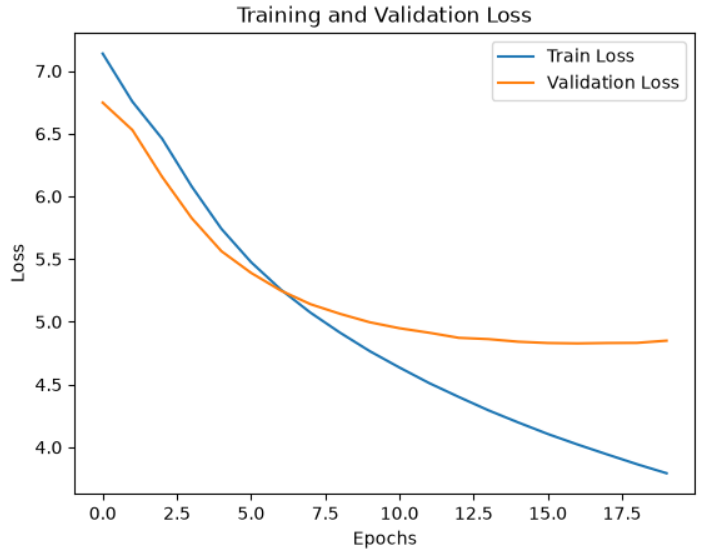

7 에폭에서 train과 val 곡선이 교차한 뒤 격차가 계속 벌어져, 20 에폭 시점 train 3.7926 /  val 4.8312로 1.03 이상의 격차가 발생하는 과적합 문제를 확인하였다. 훈련 데이터 63,610개에 비해 모델이 지나치게 크다. 

### 실험 2 : num_layer = 3 -> 2 번경

#### 1. 하이퍼파라미터 설정

|하이퍼파라미터 | 값 |
|---|---|
|seed | 42|
|embedding_dim | 128 |
|hidden_size | 256 |
|num_layers | encoder 2 / decoder 2 |
|lstm dropout | 0.4 |
|output dropout | 0.3 |
|src / tar vocab | 26000 / 14000 |
|batch_size | 256
|lr | 0.001|
|데이터 수 | train 63610(70%) / val 9086(10%) / test 18173(20%) |

#### 2. 학습 결과

| 결과 | 값 |
|---|---|
|실행 에폭 | 23 (best epoch 20) |
|Final Train Loss | 3.3380 |
|Best Val Loss | 4.7153 |
|Test Loss | 4.7335 |

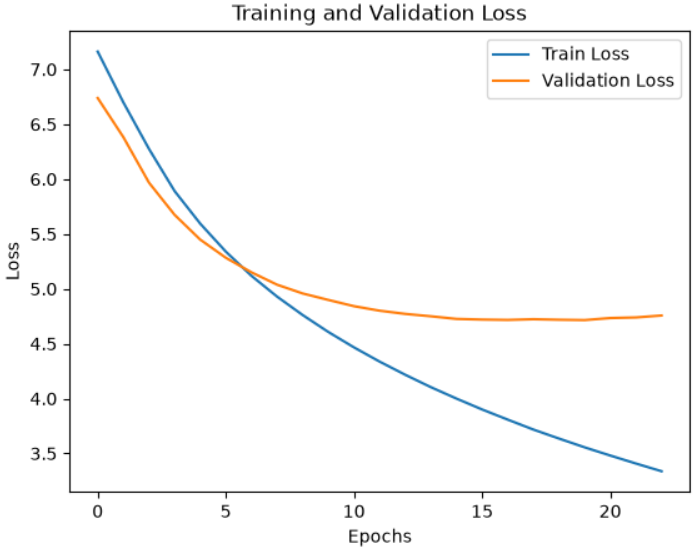

num_layers를 3에서 2로 줄인 결과, test loss가 4.8414에서 4.7335로, best val loss가 4.8278에서 4.7153으로 개선되었다. 다만 개선 폭이 0.1 수준에 그쳤다. 구조 축소로는 큰 이득을 기대하기 어렵다고 보고, 다음 실험에서는 훈련 데이터 양을 늘린다.

### 실험 3 : train / val / test 70/10/20 -> 80/10/10

#### 1. 하이퍼파라미터 설정

|하이퍼파라미터 | 값 |
|---|---|
|seed | 42|
|embedding_dim | 128 |
|hidden_size | 256 |
|num_layers | encoder 2 / decoder 2 |
|lstm dropout | 0.4 |
|output dropout | 0.3 |
|src / tar vocab | 28000 / 14000 |
|batch_size | 256
|lr | 0.001|
|데이터 수 | train 72697(80%) / val 9086(10%) / test 9086(10%) |

#### 2. 학습 결과

| 결과 | 값 |
|---|---|
|실행 에폭 | 22 (best epoch 19) |
|Final Train Loss | 3.3070 |
|Best Val Loss | 4.5881 |
|Test Loss | 4.5626 |

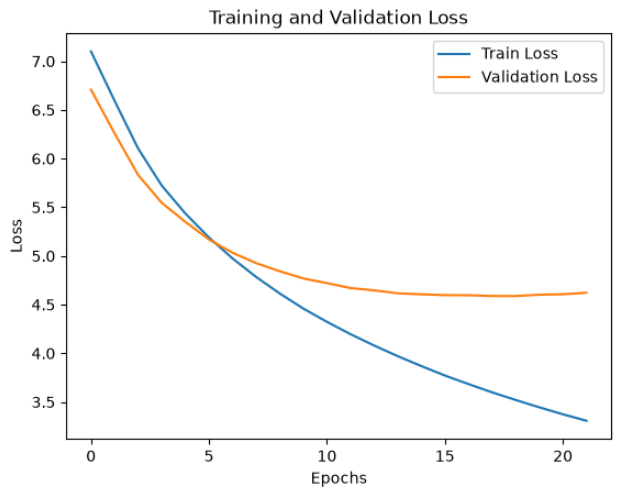

훈련 데이터를 63,610개에서 72,697개로 14.3% 늘린 결과, test loss가 4.7335에서 4.5626로 0.17 개선되었다. 이는 num_layers를 조정했을 때의 개선 폭(0.1079)보다 크며, 지금까지 시도한 변경 중 가장 큰 효과를 보였다. 모델 구조를 바꾸는 것보다 훈련 데이터를 늘리는 쪽이 더 유효한 방향임을 확인하였다.

### 회고

- Abstractive 요약의 성능을 더 끌어올리지 못한 점이 아쉽다. greedy decoding에서 비롯된 반복 문제를 해결하기 위해 beam search를 적용해 봐야겠다.
- 훈련 데이터 72,697건으로 28,000개 단어의 임베딩을 처음부터 학습시키기에는 부족했다. 사전학습된 word2vec이나 fastText로 교체하면 더 나은 성능을 기대할 수 있을 것 같다.
- 전처리에서 숫자를 제거한 것은 적절하지 않았다. 뉴스 요약에서는 숫자 자체가 핵심 정보인 경우가 많으므로 그대로 두는 편이 나았겠다.
- 성능을 높이기 위해 한 번에 한 요소씩만 바꾼 것은 좋은 선택이었다. 파라미터를 줄이려고 hidden size를 128로 낮췄을 때 오히려 성능이 나빠진 것도, 변경 범위를 좁게 가져간 덕분에 원인을 분명히 확인할 수 있었다.
- Extractive 요약과 Abstractive 요약의 결과를 직접 비교하며 각각의 문제를 짚어보는 과정에서, 문장이 매끄럽게 읽히는 것과 내용이 정확한 것은 별개라는 점을 이해할 수 있었다. 요약이 잘 생성되었다고 생각한 문장도 원문과 대조해보니 내용이 다른 경우가 꽤 있었다.
  문장이 아예 망가진 경우는 바로 걸러낼 수 있지만, 그럴듯하게 읽히는 문장은 원문을 확인하지 않으면 오류를 알아채기 어렵기 때문에 오히려 더 큰 문제를 일으킬 것 같다.